# REINFORCE: learn a continuous policy from complete episodes

REINFORCE directly adjusts a policy $\pi_\theta(a\mid s)$ to make actions followed by large returns more likely. For continuous actions, the actor samples a raw Gaussian action and squashes it into the environment bounds:

$$u_t \sim \mathcal N(\mu_\theta(s_t), \sigma_\theta), \qquad a_t = b + c\tanh(u_t).$$

After complete episodes, the policy minimizes a sampled objective based on discounted reward-to-go. This notebook implements that idea directly in PyTorch on `Pendulum-v1`.


In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

ENV_ID = "Pendulum-v1"
TOTAL_TIMESTEPS = 30_000
EPISODES_PER_UPDATE = 5
LEARNING_RATE = 3e-3
GAMMA = 0.99
MAX_GRAD_NORM = 1.0

# These small networks are faster on the CPU than on a GPU.
device = torch.device("cpu")
env = gym.make(ENV_ID)
observation_dim = int(np.prod(env.observation_space.shape))
action_dim = int(np.prod(env.action_space.shape))
observation_scale = torch.as_tensor(
    env.observation_space.high, dtype=torch.float32, device=device
)
action_low = torch.as_tensor(env.action_space.low, device=device)
action_high = torch.as_tensor(env.action_space.high, device=device)
action_scale = (action_high - action_low) / 2
action_bias = (action_high + action_low) / 2
print(f"Observation size: {observation_dim}; actions: {action_dim}; device: {device}")


Observation size: 3; actions: 1; device: cpu


## 1. Parameterize a bounded Gaussian policy

The network outputs the Gaussian mean, and `log_std` is a learned exploration parameter. A `tanh` transform followed by rescaling keeps every action inside the environment bounds. Its Jacobian correction gives the transformed action the correct log probability.

Pendulum's angular velocity has a much larger range than its other observations, so the policy divides observations by their known bounds. A second small hidden layer improves the nonlinear policy without hiding how it works.


In [2]:
def preprocess(observations):
    observations = torch.as_tensor(
        observations, dtype=torch.float32, device=device
    )
    return observations / observation_scale


policy_network = nn.Sequential(
    nn.Linear(observation_dim, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, action_dim),
).to(device)
log_std = nn.Parameter(torch.full((action_dim,), -0.5, device=device))
optimizer = torch.optim.Adam(
    [*policy_network.parameters(), log_std], lr=LEARNING_RATE
)


def action_distribution(observations):
    mean = policy_network(preprocess(observations))
    return torch.distributions.Normal(mean, log_std.clamp(-5, 2).exp())


def squash(raw_actions):
    return action_bias + action_scale * torch.tanh(raw_actions)


def log_probability(distribution, raw_actions):
    correction = torch.log(
        action_scale * (1 - torch.tanh(raw_actions).square()) + 1e-6
    )
    return (distribution.log_prob(raw_actions) - correction).sum(dim=-1)


def select_action(observation, deterministic=False):
    with torch.no_grad():
        distribution = action_distribution(np.atleast_2d(observation))
        raw_action = (
            distribution.mean if deterministic else distribution.sample()
        )
        action = squash(raw_action)
    return action.squeeze(0).cpu().numpy(), raw_action.squeeze(0).cpu().numpy()


## 2. Compute discounted reward-to-go

After an episode ends, walk backward through its rewards. The recurrence

$$G_t=r_{t+1}+\gamma G_{t+1}$$

computes every reward-to-go in one pass. There is no bootstrap term: REINFORCE waits for a complete Gymnasium episode, whether it ends through `terminated` or `truncated`.


In [3]:
def discounted_returns(rewards):
    returns = np.zeros(len(rewards), dtype=np.float32)
    reward_to_go = 0.0
    for step in reversed(range(len(rewards))):
        reward_to_go = rewards[step] + GAMMA * reward_to_go
        returns[step] = reward_to_go
    return returns


## 3. Turn returns into a policy-gradient update

For a small batch of complete episodes, minimize the negative sampled objective

$$L(\theta)=-\frac{1}{N}\sum_t G_t\log\pi_\theta(a_t\mid s_t).$$

`Pendulum-v1` episodes all have the same time limit. Standardizing returns across episodes at each timestep compares like with like and reduces gradient variance. In contrast, standardizing one episode by itself systematically labels its later, less-negative returns as advantageous even when its actions were poor.


In [4]:
def update_policy(episodes):
    observations = np.concatenate([episode[0] for episode in episodes])
    raw_actions = np.concatenate([episode[1] for episode in episodes])
    returns = np.stack(
        [discounted_returns(episode[2]) for episode in episodes]
    )
    normalized_returns = (returns - returns.mean(axis=0)) / (
        returns.std(axis=0) + 1e-8
    )

    raw_actions = torch.as_tensor(
        raw_actions, dtype=torch.float32, device=device
    )
    normalized_returns = torch.as_tensor(
        normalized_returns.reshape(-1), dtype=torch.float32, device=device
    )
    distribution = action_distribution(observations)
    loss = -(
        log_probability(distribution, raw_actions) * normalized_returns
    ).mean()

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(
        [*policy_network.parameters(), log_std], MAX_GRAD_NORM
    )
    optimizer.step()
    return loss.item()


## 4. Collect complete episodes and update

Store observations, raw actions, and rewards until an episode finishes. Every five episodes, compute their returns together and perform one policy update. The batching changes only the variance of the REINFORCE estimate; each transition remains on-policy and is used once.


In [5]:
def train(total_timesteps):
    episode_returns, losses, episodes = [], [], []
    observations, raw_actions, rewards = [], [], []
    episode_return = 0.0
    observation, _ = env.reset()

    for step in range(1, total_timesteps + 1):
        action, raw_action = select_action(observation)
        next_observation, reward, terminated, truncated, _ = env.step(action)

        observations.append(np.asarray(observation, dtype=np.float32))
        raw_actions.append(raw_action)
        rewards.append(float(reward))
        observation = next_observation

        if terminated or truncated:
            episode_return = sum(rewards)
            episode_returns.append(episode_return)
            episodes.append((observations, raw_actions, rewards))
            observations, raw_actions, rewards = [], [], []
            observation, _ = env.reset()

            if len(episodes) == EPISODES_PER_UPDATE:
                losses.append(update_policy(episodes))
                episodes = []

        print(
            f"\rStep {step}/{total_timesteps} | Episodes: {len(episode_returns)} | Episode Return: {episode_return}",
            end="",
        )

    if episodes:
        losses.append(update_policy(episodes))
    env.close()
    return episode_returns, losses


episode_returns, losses = train(TOTAL_TIMESTEPS)
print(f"\nTrained for {len(episode_returns)} episodes.")


Step 504/30000 | Episodes: 2 | Episode Return: -899.8683766015704

Step 999/30000 | Episodes: 4 | Episode Return: -1589.6171991097592

/home/pablo/workspace/AprendeRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:484: UserWarning: Found GPU0 NVIDIA GeForce GTX 960M which is of compute capability (CC) 5.0.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Your installed torch==2.14.0+cu130 does not include kernels for this GPU. Reinstall the same version against a CUDA build that does, e.g.:
  For CUDA 12.6 use pip install torch==2.14.0 --index-url https://download.pytorch.org/whl/cu126
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/pablo/workspace/AprendeRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:602: UserWarning: 
NVIDIA

Step 1584/30000 | Episodes: 7 | Episode Return: -1169.0016036062316

Step 2110/30000 | Episodes: 10 | Episode Return: -1177.2212147086975

...

Step 28099/30000 | Episodes: 140 | Episode Return: -1524.8405552535805

Step 28665/30000 | Episodes: 143 | Episode Return: -952.2288163489088

Step 29246/30000 | Episodes: 146 | Episode Return: -1096.645216334593

Step 29781/30000 | Episodes: 148 | Episode Return: -1174.2501474670169

Step 30000/30000 | Episodes: 150 | Episode Return: -1179.6805715937837
Trained for 150 episodes.


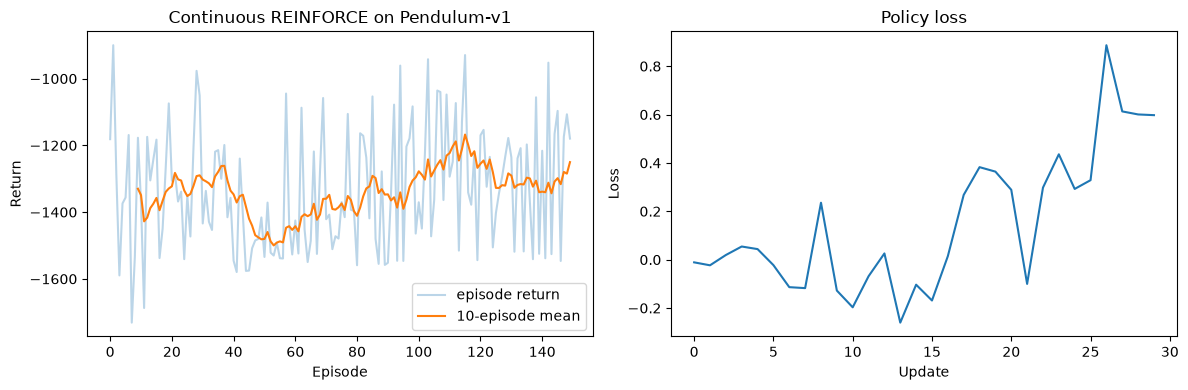

In [6]:
returns = np.asarray(episode_returns)
window = min(10, len(returns))
moving_average = np.convolve(
    returns, np.ones(window) / window, mode="valid"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(returns, alpha=0.3, label="episode return")
axes[0].plot(
    np.arange(window - 1, len(returns)),
    moving_average,
    label=f"{window}-episode mean",
)
axes[0].set(
    title=f"Continuous REINFORCE on {ENV_ID}",
    xlabel="Episode",
    ylabel="Return",
)
axes[0].legend()
axes[1].plot(losses)
axes[1].set(title="Policy loss", xlabel="Update", ylabel="Loss")
plt.tight_layout()


## 5. Evaluate the modal policy

Training samples actions, but evaluation squashes the Gaussian mean. A separate environment measures the deterministic policy without disturbing training state.


In [7]:
env = gym.make(ENV_ID, render_mode="human")
episode_returns = []

for episode in range(5):
    observation, _ = env.reset()
    episode_return = 0.0
    for step in range(1000):
        action, _ = select_action(observation, deterministic=True)
        observation, reward, terminated, truncated, _ = env.step(action)
        episode_return += reward
        print(
            f"Episode {episode + 1}: step={step + 1}, "
            f"return={episode_return:.1f}",
            end="\r",
        )
        if terminated or truncated:
            break
    episode_returns.append(episode_return)
    print()

env.close()
print(f"Mean return: {np.mean(episode_returns):.1f} +/- {np.std(episode_returns):.1f}")


Episode 1: step=200, return=-1182.7


Episode 2: step=200, return=-1190.0


Episode 3: step=200, return=-1173.3


Episode 4: step=200, return=-1011.6


Episode 5: step=200, return=-1349.4
Mean return: -1181.4 +/- 107.0
